In [1]:
%%capture --no-stderr
%pip install --quiet -U langchain_core langgraph langchain_ollama transformers

In [2]:
import os, getpass

def _set_env(var: str):
    # Check if the variable is set in the OS environment
    env_value = os.environ.get(var)
    if not env_value:
        # If not set, prompt the user for input
        env_value = getpass.getpass(f"{var}: ")
    
    # Set the environment variable for the current process
    os.environ[var] = env_value

_set_env("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "langchain-academy"

In [3]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
messages = [AIMessage(f"So you said you were researching ocean mammals?", name="Bot")]
messages.append(HumanMessage(f"Yes, I know about whales. But what others should I learn about?", name="Lance"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?


In [4]:
from langchain_ollama import ChatOllama
# Initialize the Ollama LLM with the Llama 3 model
llm = ChatOllama(model="llama3.1", temperature=0)

llm.invoke(messages)

AIMessage(content='There are many fascinating ocean mammals beyond whales! Here are some examples:\n\n1. **Dolphins**: Like whales, dolphins are cetaceans and are known for their intelligence, social behavior, and playful nature.\n2. **Porpoises**: These small toothed cetaceans are often confused with dolphins, but they have a more robust body shape and a distinctive triangular dorsal fin.\n3. **Manatees** (also known as sea cows): These large, slow-moving herbivores are found in shallow waters of the Caribbean and Gulf of Mexico.\n4. **Dugongs**: Similar to manatees, dugongs are also large, slow-moving herbivores that inhabit tropical waters of the Indo-Pacific region.\n5. **Seals** (e.g., harbor seals, elephant seals): These fin-footed mammals are adapted for life on land and in water, with a streamlined body shape and flippers instead of legs.\n6. **Sea lions**: Like seals, sea lions are pinnipeds that have a more robust body shape and can walk on their hind flippers.\n7. **Walruses

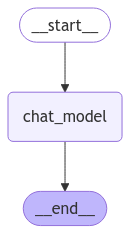

In [5]:
from IPython.display import Image, display
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END

# Node
def chat_model_node(state: MessagesState):
    return {"messages": llm.invoke(state["messages"])}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

There are many fascinating ocean mammals beyond whales! Here are some examples:

1. **Dolphins**: Like whales, dolphins are cetaceans and are known for their intelligence, social behavior, and playful nature.
2. **Porpoises**: These small toothed cetaceans are often confused with dolphins, but they have a more robust body shape and a distinctive triangular dorsal fin.
3. **Manatees** (also known as sea cows): These large, slow-moving herbivores are found in shallow waters of the Caribbean and Gulf of Mexico.
4. **Dugongs**: Similar to manatees, dugongs are also large, slow-moving herbivores that inhabit tropical 

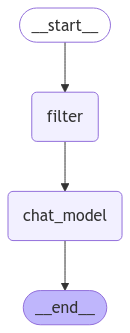

In [7]:
from langchain_core.messages import RemoveMessage

# Nodes
def filter_messages(state: MessagesState):
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"messages": delete_messages}

def chat_model_node(state: MessagesState):    
    return {"messages": [llm.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("filter", filter_messages)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "filter")
builder.add_edge("filter", "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
# Message list with a preamble
messages = [AIMessage("Hi.", name="Bot", id="1")]
messages.append(HumanMessage("Hi.", name="Lance", id="2"))
messages.append(AIMessage("So you said you were researching ocean mammals?", name="Bot", id="3"))
messages.append(HumanMessage("Yes, I know about whales. But what others should I learn about?", name="Lance", id="4"))

# Invoke
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

There are many fascinating ocean mammals beyond whales! Here are some examples:

1. **Dolphins**: Like whales, dolphins are cetaceans and are known for their intelligence, social behavior, and playful nature.
2. **Porpoises**: These small toothed cetaceans are often confused with dolphins, but they have a more robust body shape and a distinctive triangular dorsal fin.
3. **Manatees** (also known as sea cows): These large, slow-moving herbivores are found in shallow waters of the Caribbean and Gulf of Mexico.
4. **Dugongs**: Similar to manatees, dugongs are also large, slow-moving herbivores that inhabit tropical 

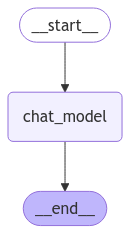

In [9]:
# Node
def chat_model_node(state: MessagesState):
    return {"messages": [llm.invoke(state["messages"][-1:])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me more about Narwhals!", name="Lance"))

In [11]:
for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Lance

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

There are many fascinating ocean mammals beyond whales! Here are some examples:

1. **Dolphins**: Like whales, dolphins are cetaceans and are known for their intelligence, social behavior, and playful nature.
2. **Porpoises**: These small toothed cetaceans are often confused with dolphins, but they have a more robust body shape and a distinctive triangular dorsal fin.
3. **Manatees** (also known as sea cows): These large, 

In [12]:
# Invoke, using message filtering
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Lance

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

There are many fascinating ocean mammals beyond whales! Here are some examples:

1. **Dolphins**: Like whales, dolphins are cetaceans and are known for their intelligence, social behavior, and playful nature.
2. **Porpoises**: These small toothed cetaceans are often confused with dolphins, but they have a more robust body shape and a distinctive triangular dorsal fin.
3. **Manatees** (also known as sea cows): These large, 

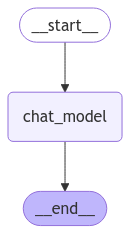

In [13]:
from langchain_core.messages import trim_messages

# Node
def chat_model_node(state: MessagesState):
    messages = trim_messages(
            state["messages"],
            max_tokens=100,
            strategy="last",
            token_counter=ChatOllama(model="llama3.1", temperature=0),
            allow_partial=False,
        )
    return {"messages": [llm.invoke(messages)]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me where Orcas live!", name="Lance"))

In [15]:
# Example of trimming messages
trim_messages(
            messages,
            max_tokens=100,
            strategy="last",
            token_counter=ChatOllama(model="llama3.1", temperature=0),
            allow_partial=False
        )

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


[HumanMessage(content='Tell me where Orcas live!', additional_kwargs={}, response_metadata={}, name='Lance')]

In [16]:
# Invoke, using message trimming in the chat_model_node 
messages_out_trim = graph.invoke({'messages': messages})

In [17]:
for m in messages_out_trim['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Lance

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

There are many fascinating ocean mammals beyond whales! Here are some examples:

1. **Dolphins**: Like whales, dolphins are cetaceans and are known for their intelligence, social behavior, and playful nature.
2. **Porpoises**: These small toothed cetaceans are often confused with dolphins, but they have a more robust body shape and a distinctive triangular dorsal fin.
3. **Manatees** (also known as sea cows): These large, 